# 02 — Primary Crusher Energy-Demand Modelling

**Project:** Probabilistic, Adaptive, and Interpretable Prediction of Primary Crusher Energy Demand from Blast-Design Data in a Peruvian Open-Pit Copper Mine

This notebook consumes the existing CSV. It does not generate records.

It includes:

- chronological train/test separation;
- three prediction targets;
- baseline and machine-learning comparisons;
- MAE, RMSE, **MAPE**, WAPE, and R²;
- actual-versus-predicted, temporal, residual, and model-comparison charts;
- probabilistic Q10/Q50/Q90 prediction for average power;
- scheduled adaptive evaluation using an expanding window;
- permutation-based feature importance.

> **Interpretation boundary:** metrics describe only the supplied CSV. The provenance and status of that CSV must be reported accurately.

In [1]:
from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    r2_score,
)
from sklearn.inspection import permutation_importance
import joblib

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")
RANDOM_STATE = 42

In [2]:
def locate_project_file(relative_path: str) -> Path:
    candidates = [
        Path(relative_path),
        Path.cwd() / relative_path,
        Path.cwd().parent / relative_path,
        Path.cwd().parent.parent / relative_path,
        Path.cwd().parent / "data" / "processed" / "blast_crusher.csv",
    ]
    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate.exists():
            return candidate
    raise FileNotFoundError(
        "No se encontró blast_crusher.csv. "
        "Colócalo en 05_pipeline/data/processed/blast_crusher.csv"
    )

DATA_PATH = locate_project_file("../data/processed/blast_crusher.csv")
PROJECT_DIR = DATA_PATH.parents[2]
RESULTS_DIR = PROJECT_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(DATA_PATH)
df["firing_datetime"] = pd.to_datetime(df["firing_datetime"], errors="raise")
df = df.sort_values("firing_datetime").reset_index(drop=True)

print("Dataset:", DATA_PATH)
print("Rows:", f"{len(df):,}")
display(df.head())

Dataset: E:\Luis\Luis_Quispe_Metodos\research-methods-deliverables\05_pipeline\data\processed\blast_crusher.csv
Rows: 2,625


,blast_name,year,firing_datetime,holes_count,bench_anon,powder_factor_kg_t,ucs_mpa,rmr,moisture_pct,mean_payload_t,throughput_tph,traceability_confidence,crusher_id,average_power_kw,specific_energy_kwh_t,peak_power_kw,data_status
0,BLST_2024_0001,2024,2024-01-01 00:00:00.000000000,333,3690,0.5527,141.6740,38.9396,1.8875,311.5699,"2,980.6462",HIGH,CR01,"3,058.4873",1.0261,"3,502.0080",SYNTHETIC
1,BLST_2024_0002,2024,2024-01-01 08:11:40.467726847,79,4110,0.3637,185.7620,35.6509,2.7157,375.8702,"2,913.8146",MEDIUM,CR01,"3,035.4278",1.0417,"3,370.1867",SYNTHETIC
2,BLST_2024_0003,2024,2024-01-01 16:23:20.935453695,30,3810,0.3272,121.3320,41.4300,3.3138,306.3927,"2,265.5448",HIGH,CR01,"2,325.7340",1.0266,"2,617.5062",SYNTHETIC
3,BLST_2024_0004,2024,2024-01-02 00:35:01.403180542,22,3645,0.3846,157.3693,61.1898,1.0683,354.3061,"3,390.4045",HIGH,CR02,"2,993.3771",0.8829,"3,480.7528",SYNTHETIC
4,BLST_2024_0005,2024,2024-01-02 08:46:41.870907390,154,4080,0.4264,161.9015,49.6736,2.8749,335.3122,"2,303.8583",HIGH,CR01,"2,619.1586",1.1369,"3,022.9609",SYNTHETIC


## 1. Features, targets, and chronological split

In [3]:
FEATURES = [
    "holes_count",
    "bench_anon",
    "powder_factor_kg_t",
    "ucs_mpa",
    "rmr",
    "moisture_pct",
    "mean_payload_t",
    "throughput_tph",
    "traceability_confidence",
    "crusher_id",
]

NUMERIC_FEATURES = [
    "holes_count",
    "bench_anon",
    "powder_factor_kg_t",
    "ucs_mpa",
    "rmr",
    "moisture_pct",
    "mean_payload_t",
    "throughput_tph",
]

CATEGORICAL_FEATURES = [
    "traceability_confidence",
    "crusher_id",
]

TARGETS = [
    "average_power_kw",
    "specific_energy_kwh_t",
    "peak_power_kw",
]

train_df = df[df["year"].isin([2024, 2025])].copy()
test_df = df[df["year"] == 2026].copy()

assert len(train_df) > 0 and len(test_df) > 0
assert train_df["firing_datetime"].max() < test_df["firing_datetime"].min()

print(f"Training rows: {len(train_df):,}")
print(f"Testing rows:  {len(test_df):,}")
print("Training period:", train_df["firing_datetime"].min(), "to", train_df["firing_datetime"].max())
print("Testing period: ", test_df["firing_datetime"].min(), "to", test_df["firing_datetime"].max())

Training rows: 2,109
Testing rows:  516
Training period: 2024-01-01 00:00:00 to 2025-12-31 00:00:00
Testing period:  2026-01-01 00:00:00 to 2026-06-17 00:00:00


In [4]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            Pipeline([
                ("imputer", SimpleImputer(strategy="median")),
                ("scaler", StandardScaler()),
            ]),
            NUMERIC_FEATURES,
        ),
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            CATEGORICAL_FEATURES,
        ),
    ],
    remainder="drop",
)

## 2. Metrics, including MAPE

In [5]:
def wape(y_true, y_pred) -> float:
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    denominator = np.abs(y_true).sum()
    return float(np.abs(y_true - y_pred).sum() / denominator * 100) if denominator else np.nan

def regression_metrics(y_true, y_pred) -> dict:
    return {
        "MAE": float(mean_absolute_error(y_true, y_pred)),
        "RMSE": float(mean_squared_error(y_true, y_pred) ** 0.5),
        "MAPE_pct": float(mean_absolute_percentage_error(y_true, y_pred) * 100),
        "WAPE_pct": wape(y_true, y_pred),
        "R2": float(r2_score(y_true, y_pred)),
    }

## 3. Train and compare models for all three targets

In [6]:
MODEL_FACTORIES = {
    "Historical mean": lambda: DummyRegressor(strategy="mean"),
    "Linear regression": lambda: LinearRegression(),
    "Random forest": lambda: RandomForestRegressor(
        n_estimators=350,
        min_samples_leaf=3,
        max_features=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
    ),
}

all_metrics = []
predictions = test_df[["blast_name", "firing_datetime", "year"]].copy()
trained_models = {}

for target in TARGETS:
    X_train = train_df[FEATURES]
    y_train = train_df[target]
    X_test = test_df[FEATURES]
    y_test = test_df[target]

    predictions[f"actual__{target}"] = y_test.to_numpy()

    for model_name, factory in MODEL_FACTORIES.items():
        pipeline = Pipeline([
            ("preprocess", clone(preprocessor)),
            ("model", factory()),
        ])
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        key = (target, model_name)
        trained_models[key] = pipeline
        predictions[f"pred__{target}__{model_name.replace(' ', '_').lower()}"] = y_pred

        row = {
            "target": target,
            "model": model_name,
            **regression_metrics(y_test, y_pred),
        }
        all_metrics.append(row)

metrics_df = pd.DataFrame(all_metrics).sort_values(["target", "MAPE_pct"])
display(metrics_df)

metrics_df.to_csv(RESULTS_DIR / "model_metrics_all_targets.csv", index=False)
predictions.to_csv(RESULTS_DIR / "predictions_all_targets.csv", index=False)

,target,model,MAE,RMSE,MAPE_pct,WAPE_pct,R2
1,average_power_kw,Linear regression,106.0039,135.6681,3.9348,3.8688,0.8573
2,average_power_kw,Random forest,121.0609,154.7229,4.4826,4.4183,0.8144
0,average_power_kw,Historical mean,283.3376,359.6204,10.7304,10.3408,-0.0024
7,peak_power_kw,Linear regression,187.0436,234.5964,5.8714,5.7820,0.7426
8,peak_power_kw,Random forest,201.3686,252.1561,6.3319,6.2248,0.7027
6,peak_power_kw,Historical mean,370.1184,462.9601,11.8680,11.4413,-0.0023
4,specific_energy_kwh_t,Linear regression,0.0451,0.0599,4.1349,4.1421,0.7036
5,specific_energy_kwh_t,Random forest,0.0472,0.0623,4.3140,4.3433,0.6795
3,specific_energy_kwh_t,Historical mean,0.0840,0.1100,7.6434,7.7192,-0.0001


## 4. Model-comparison chart using MAPE

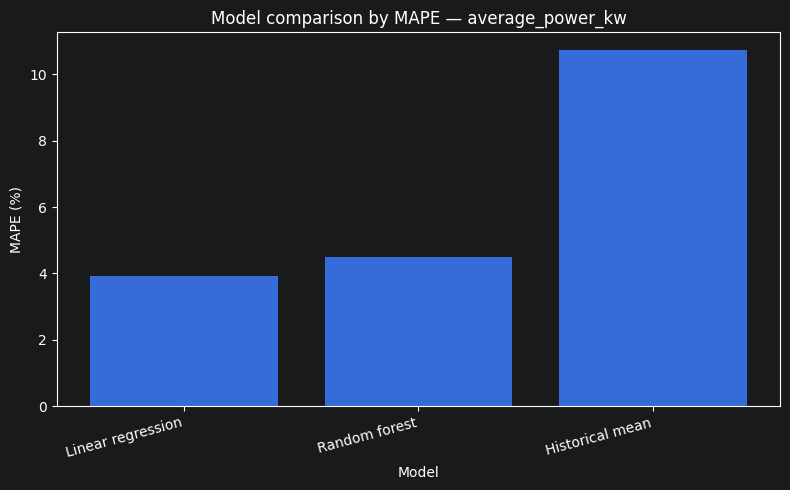

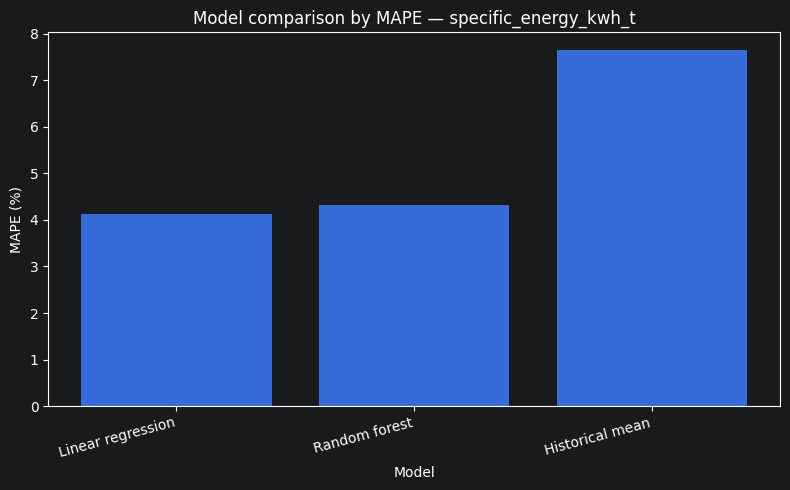

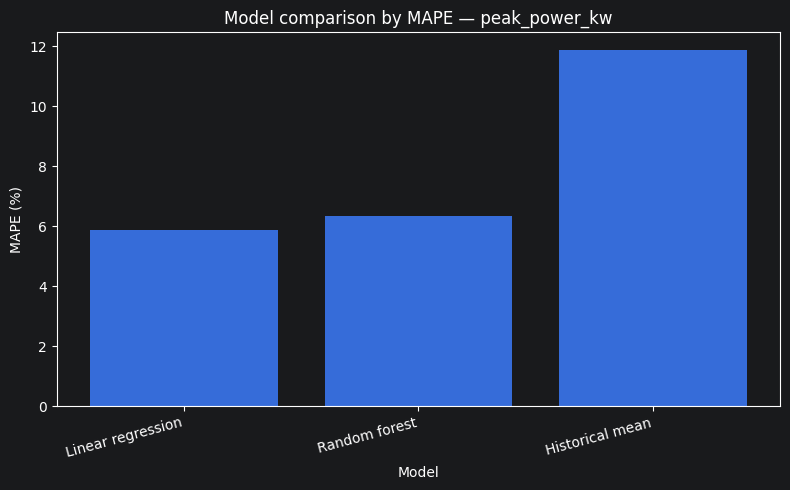

In [7]:
for target in TARGETS:
    target_metrics = metrics_df[metrics_df["target"] == target].sort_values("MAPE_pct")

    plt.figure(figsize=(8, 5))
    plt.bar(target_metrics["model"], target_metrics["MAPE_pct"])
    plt.title(f"Model comparison by MAPE — {target}")
    plt.xlabel("Model")
    plt.ylabel("MAPE (%)")
    plt.xticks(rotation=15, ha="right")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / f"mape_comparison_{target}.png", dpi=170)
    plt.show()

## 5. Select the best model for average power

In [8]:
PRIMARY_TARGET = "average_power_kw"
primary_metrics = metrics_df[metrics_df["target"] == PRIMARY_TARGET].sort_values("MAPE_pct")
best_model_name = primary_metrics.iloc[0]["model"]
best_model = trained_models[(PRIMARY_TARGET, best_model_name)]

actual = test_df[PRIMARY_TARGET].to_numpy()
prediction_column = f"pred__{PRIMARY_TARGET}__{best_model_name.replace(' ', '_').lower()}"
predicted = predictions[prediction_column].to_numpy()
residuals = actual - predicted

print("Best model by MAPE:", best_model_name)
display(primary_metrics)

Best model by MAPE: Linear regression


,target,model,MAE,RMSE,MAPE_pct,WAPE_pct,R2
1,average_power_kw,Linear regression,106.0039,135.6681,3.9348,3.8688,0.8573
2,average_power_kw,Random forest,121.0609,154.7229,4.4826,4.4183,0.8144
0,average_power_kw,Historical mean,283.3376,359.6204,10.7304,10.3408,-0.0024


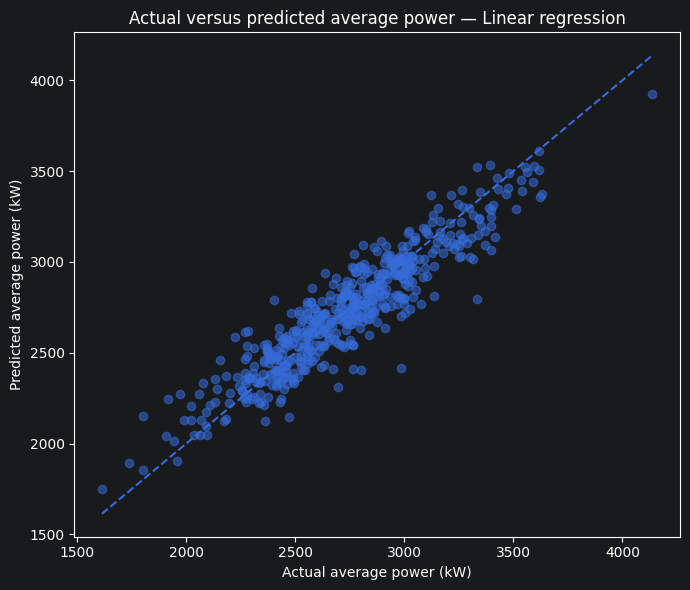

In [9]:
plt.figure(figsize=(7, 6))
plt.scatter(actual, predicted, alpha=0.55)
minimum = min(actual.min(), predicted.min())
maximum = max(actual.max(), predicted.max())
plt.plot([minimum, maximum], [minimum, maximum], linestyle="--")
plt.title(f"Actual versus predicted average power — {best_model_name}")
plt.xlabel("Actual average power (kW)")
plt.ylabel("Predicted average power (kW)")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "actual_vs_predicted_average_power.png", dpi=170)
plt.show()

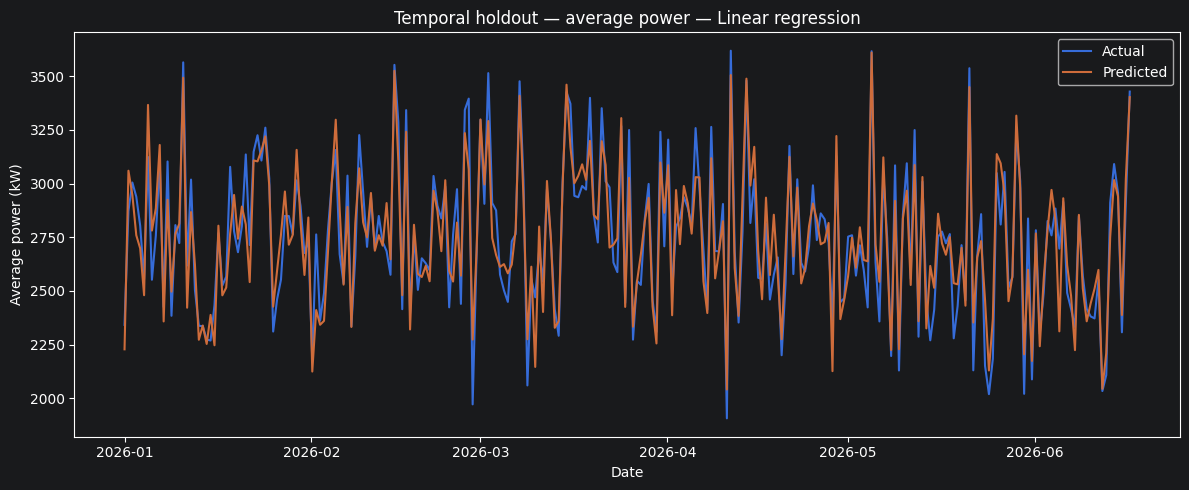

In [10]:
temporal_plot = test_df[["firing_datetime", PRIMARY_TARGET]].copy()
temporal_plot["prediction"] = predicted
temporal_plot = temporal_plot.sort_values("firing_datetime")
step = max(1, len(temporal_plot) // 180)
temporal_sample = temporal_plot.iloc[::step]

plt.figure(figsize=(12, 5))
plt.plot(temporal_sample["firing_datetime"], temporal_sample[PRIMARY_TARGET], label="Actual")
plt.plot(temporal_sample["firing_datetime"], temporal_sample["prediction"], label="Predicted")
plt.title(f"Temporal holdout — average power — {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Average power (kW)")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "temporal_actual_vs_predicted_average_power.png", dpi=170)
plt.show()

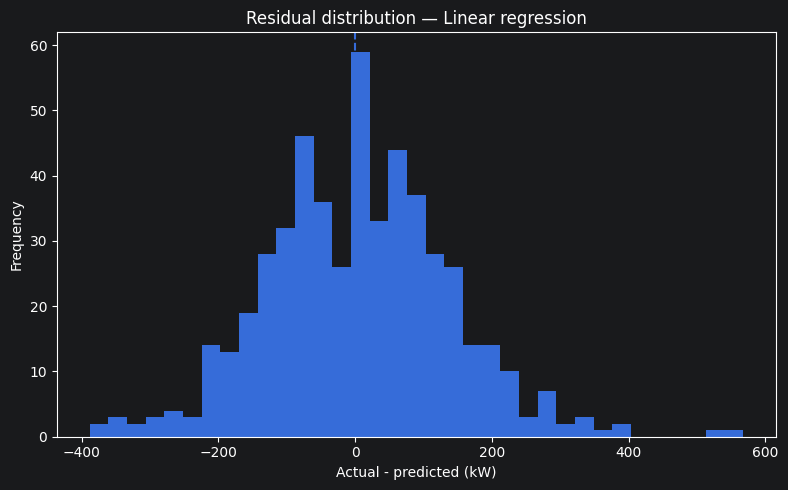

In [11]:
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=35)
plt.axvline(0, linestyle="--")
plt.title(f"Residual distribution — {best_model_name}")
plt.xlabel("Actual - predicted (kW)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "residual_distribution_average_power.png", dpi=170)
plt.show()

## 6. Probabilistic prediction: Q10, Q50, and Q90

In [12]:
X_train = train_df[FEATURES]
y_train = train_df[PRIMARY_TARGET]
X_test = test_df[FEATURES]
y_test = test_df[PRIMARY_TARGET]

quantile_models = {}
quantile_predictions = {}

for label, alpha in [("Q10", 0.10), ("Q50", 0.50), ("Q90", 0.90)]:
    model = Pipeline([
        ("preprocess", clone(preprocessor)),
        ("model", GradientBoostingRegressor(
            loss="quantile",
            alpha=alpha,
            n_estimators=250,
            learning_rate=0.04,
            max_depth=3,
            min_samples_leaf=8,
            random_state=RANDOM_STATE,
        )),
    ])
    model.fit(X_train, y_train)
    quantile_models[label] = model
    quantile_predictions[label] = model.predict(X_test)

q10 = quantile_predictions["Q10"]
q50 = quantile_predictions["Q50"]
q90 = quantile_predictions["Q90"]

coverage = float(np.mean((y_test.to_numpy() >= q10) & (y_test.to_numpy() <= q90)) * 100)
mean_interval_width = float(np.mean(q90 - q10))
median_metrics = regression_metrics(y_test, q50)

probabilistic_summary = pd.DataFrame([{
    "target": PRIMARY_TARGET,
    "interval": "Q10-Q90",
    "empirical_coverage_pct": coverage,
    "mean_interval_width_kw": mean_interval_width,
    "Q50_MAE": median_metrics["MAE"],
    "Q50_RMSE": median_metrics["RMSE"],
    "Q50_MAPE_pct": median_metrics["MAPE_pct"],
    "Q50_R2": median_metrics["R2"],
}])

display(probabilistic_summary)
probabilistic_summary.to_csv(RESULTS_DIR / "probabilistic_summary.csv", index=False)

,target,interval,empirical_coverage_pct,mean_interval_width_kw,Q50_MAE,Q50_RMSE,Q50_MAPE_pct,Q50_R2
0,average_power_kw,Q10-Q90,75.1938,336.4872,114.0382,145.1058,4.2399,0.8368


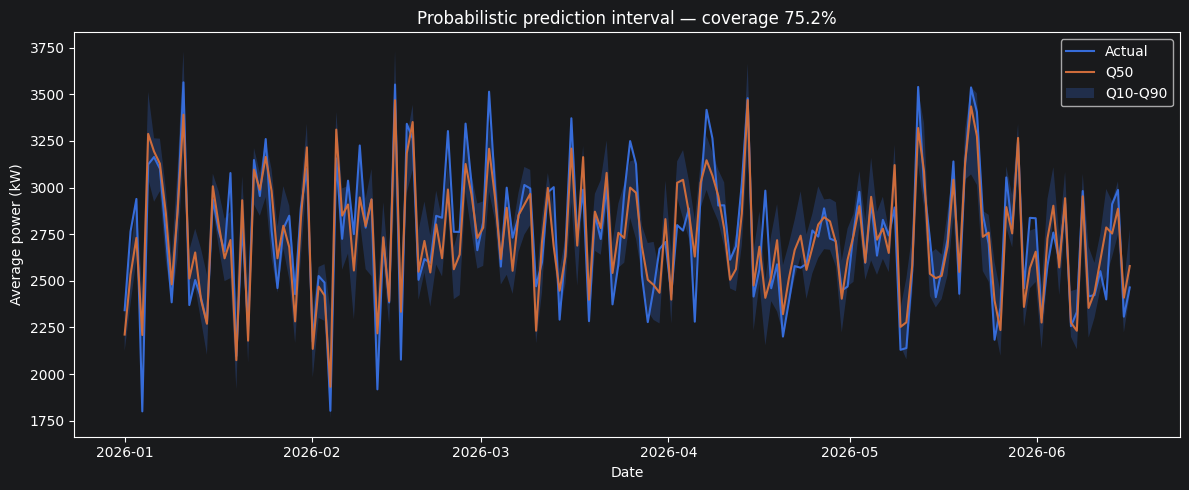

In [13]:
quantile_plot = test_df[["firing_datetime", PRIMARY_TARGET]].copy()
quantile_plot["Q10"] = q10
quantile_plot["Q50"] = q50
quantile_plot["Q90"] = q90
quantile_plot = quantile_plot.sort_values("firing_datetime")
step = max(1, len(quantile_plot) // 150)
qp = quantile_plot.iloc[::step]

plt.figure(figsize=(12, 5))
plt.plot(qp["firing_datetime"], qp[PRIMARY_TARGET], label="Actual")
plt.plot(qp["firing_datetime"], qp["Q50"], label="Q50")
plt.fill_between(qp["firing_datetime"], qp["Q10"], qp["Q90"], alpha=0.25, label="Q10-Q90")
plt.title(f"Probabilistic prediction interval — coverage {coverage:.1f}%")
plt.xlabel("Date")
plt.ylabel("Average power (kW)")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / "probabilistic_interval_average_power.png", dpi=170)
plt.show()

## 7. Scheduled adaptive evaluation with an expanding window

In [14]:
adaptive_rows = []
adaptive_predictions = []

for quarter in sorted(test_df["firing_datetime"].dt.to_period("Q").unique()):
    quarter_mask = test_df["firing_datetime"].dt.to_period("Q") == quarter
    quarter_test = test_df[quarter_mask].copy()

    training_cutoff = quarter_test["firing_datetime"].min()
    adaptive_train = df[df["firing_datetime"] < training_cutoff].copy()

    if len(adaptive_train) == 0 or len(quarter_test) == 0:
        continue

    adaptive_model = Pipeline([
        ("preprocess", clone(preprocessor)),
        ("model", LinearRegression()),
    ])
    adaptive_model.fit(adaptive_train[FEATURES], adaptive_train[PRIMARY_TARGET])
    quarter_pred = adaptive_model.predict(quarter_test[FEATURES])

    adaptive_rows.append({
        "quarter": str(quarter),
        "training_rows": int(len(adaptive_train)),
        "test_rows": int(len(quarter_test)),
        **regression_metrics(quarter_test[PRIMARY_TARGET], quarter_pred),
    })

    quarter_output = quarter_test[["blast_name", "firing_datetime", PRIMARY_TARGET]].copy()
    quarter_output["prediction"] = quarter_pred
    quarter_output["quarter"] = str(quarter)
    adaptive_predictions.append(quarter_output)

adaptive_metrics = pd.DataFrame(adaptive_rows)
display(adaptive_metrics)
adaptive_metrics.to_csv(RESULTS_DIR / "adaptive_expanding_window_metrics.csv", index=False)

if adaptive_predictions:
    pd.concat(adaptive_predictions, ignore_index=True).to_csv(
        RESULTS_DIR / "adaptive_expanding_window_predictions.csv",
        index=False,
    )

,quarter,training_rows,test_rows,MAE,RMSE,MAPE_pct,WAPE_pct,R2
0,2026Q1,2109,278,106.0803,133.0697,3.9371,3.8557,0.8530
1,2026Q2,2387,238,105.9096,138.6871,3.9337,3.8840,0.8613


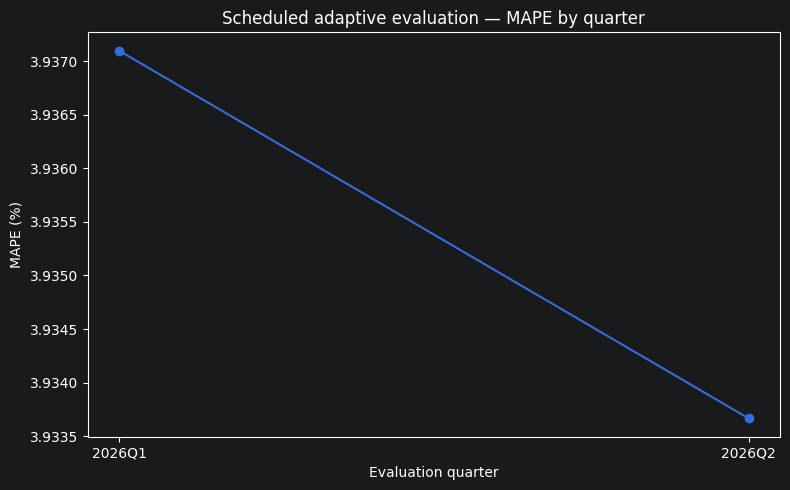

In [15]:
if not adaptive_metrics.empty:
    plt.figure(figsize=(8, 5))
    plt.plot(adaptive_metrics["quarter"], adaptive_metrics["MAPE_pct"], marker="o")
    plt.title("Scheduled adaptive evaluation — MAPE by quarter")
    plt.xlabel("Evaluation quarter")
    plt.ylabel("MAPE (%)")
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / "adaptive_mape_by_quarter.png", dpi=170)
    plt.show()

## 8. Interpretability using permutation importance

In [16]:
importance = permutation_importance(
    best_model,
    test_df[FEATURES],
    test_df[PRIMARY_TARGET],
    scoring="neg_mean_absolute_error",
    n_repeats=15,
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

importance_df = pd.DataFrame({
    "feature": FEATURES,
    "importance_mean": importance.importances_mean,
    "importance_std": importance.importances_std,
}).sort_values("importance_mean", ascending=False)

display(importance_df)
importance_df.to_csv(RESULTS_DIR / "permutation_importance_average_power.csv", index=False)

,feature,importance_mean,importance_std
7,throughput_tph,244.8958,9.6126
3,ucs_mpa,41.7413,3.1334
0,holes_count,41.4122,4.0684
9,crusher_id,20.2833,1.5936
2,powder_factor_kg_t,3.6643,0.9405
5,moisture_pct,1.1717,0.8357
4,rmr,0.0565,0.1168
6,mean_payload_t,0.0059,0.0054
1,bench_anon,0.0025,0.0352
8,traceability_confidence,-0.0472,0.1075


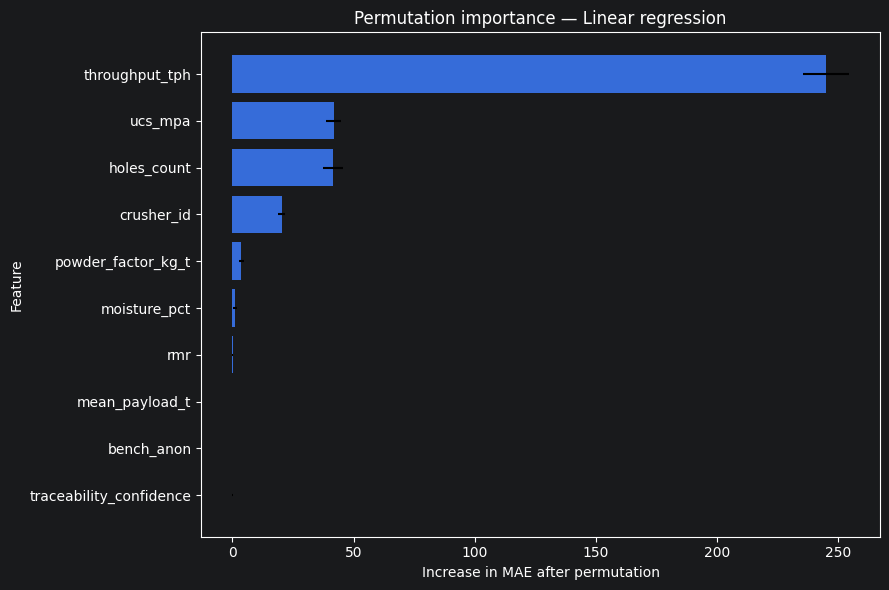

In [17]:
plot_importance = importance_df.sort_values("importance_mean")

plt.figure(figsize=(9, 6))
plt.barh(
    plot_importance["feature"],
    plot_importance["importance_mean"],
    xerr=plot_importance["importance_std"],
)
plt.title(f"Permutation importance — {best_model_name}")
plt.xlabel("Increase in MAE after permutation")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(RESULTS_DIR / "permutation_importance_average_power.png", dpi=170)
plt.show()

## 9. Save the selected model and execution summary

In [18]:
model_path = RESULTS_DIR / "selected_average_power_model.joblib"
joblib.dump(best_model, model_path)

execution_summary = {
    "dataset_path": str(DATA_PATH),
    "rows": int(len(df)),
    "train_rows": int(len(train_df)),
    "test_rows": int(len(test_df)),
    "train_years": [2024, 2025],
    "test_years": [2026],
    "primary_target": PRIMARY_TARGET,
    "best_model_by_mape": best_model_name,
    "best_model_metrics": primary_metrics.iloc[0].to_dict(),
    "probabilistic_coverage_pct": coverage,
    "probabilistic_mean_interval_width_kw": mean_interval_width,
    "data_status_counts": df["data_status"].value_counts(dropna=False).to_dict(),
}

with open(RESULTS_DIR / "model_execution_summary.json", "w", encoding="utf-8") as file:
    json.dump(execution_summary, file, indent=2, ensure_ascii=False, default=str)

print("Model saved:", model_path)
print("All outputs saved in:", RESULTS_DIR)
display(pd.DataFrame([execution_summary["best_model_metrics"]]))

Model saved: E:\Luis\Luis_Quispe_Metodos\research-methods-deliverables\05_pipeline\results\selected_average_power_model.joblib
All outputs saved in: E:\Luis\Luis_Quispe_Metodos\research-methods-deliverables\05_pipeline\results


,target,model,MAE,RMSE,MAPE_pct,WAPE_pct,R2
0,average_power_kw,Linear regression,106.0039,135.6681,3.9348,3.8688,0.8573


## Final interpretation guide

- **MAE** reports the mean absolute error in the target's original unit.
- **RMSE** gives more weight to large errors.
- **MAPE** reports mean absolute percentage error.
- **WAPE** reports total absolute error relative to total observed magnitude.
- **R²** measures explained variance relative to a mean baseline.
- **Q10-Q90 coverage** evaluates whether the probabilistic interval contains the observed value at the intended frequency.
- **Expanding-window evaluation** is a scheduled adaptation benchmark, not proof that online learning is necessary.
- **Permutation importance** describes predictive dependence, not causality.